In [1]:
train="/content/train.csv"
test="/content/test.csv"

In [2]:
import pandas as pd

In [3]:
df=pd.read_csv(train)
df=df.drop('id',axis=1)
df.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   annual_income         593994 non-null  float64
 1   debt_to_income_ratio  593994 non-null  float64
 2   credit_score          593994 non-null  int64  
 3   loan_amount           593994 non-null  float64
 4   interest_rate         593994 non-null  float64
 5   gender                593994 non-null  object 
 6   marital_status        593994 non-null  object 
 7   education_level       593994 non-null  object 
 8   employment_status     593994 non-null  object 
 9   loan_purpose          593994 non-null  object 
 10  grade_subgrade        593994 non-null  object 
 11  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 54.4+ MB


In [5]:
df.shape

(593994, 12)

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
annual_income,593994.0,48212.202976,26711.942078,6002.430,27934.400,46557.680,60981.320,393381.740
debt_to_income_ratio,593994.0,0.120696,0.068573,0.011,0.072,0.096,0.156,0.627
credit_score,593994.0,680.916009,55.424956,395.000,646.000,682.000,719.000,849.000
loan_amount,593994.0,15020.297629,6926.530568,500.090,10279.620,15000.220,18858.580,48959.950
interest_rate,593994.0,12.356345,2.008959,3.200,10.990,12.370,13.680,20.990
loan_paid_back,593994.0,0.798820,0.400883,0.000,1.000,1.000,1.000,1.000


In [7]:
df.isna().any(axis=1).value_counts()

,count
False,593994


In [8]:
df.isnull().any(axis=0).value_counts()

,count
False,12


In [9]:
df.duplicated().value_counts()

,count
False,593994


## Data Visualization

In [10]:
import matplotlib.pyplot as plt

In [7]:
numeric_features=['annual_income','debt_to_income_ratio','credit_score','loan_amount','interest_rate']
categorical_features=['gender','marital_status','education_level','employment_status','loan_purpose']

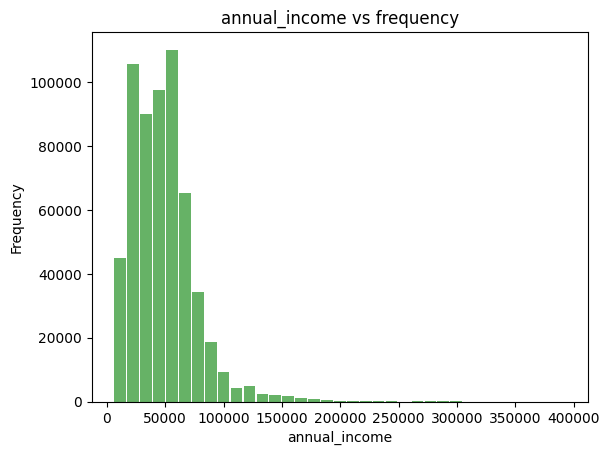

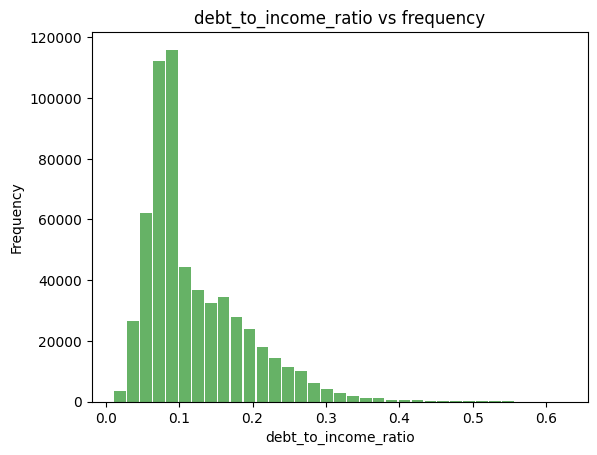

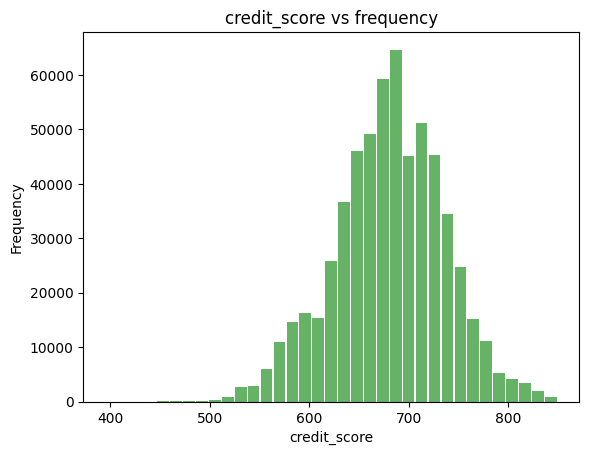

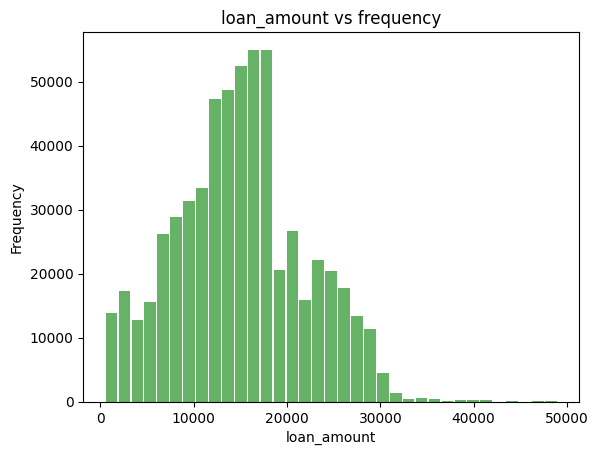

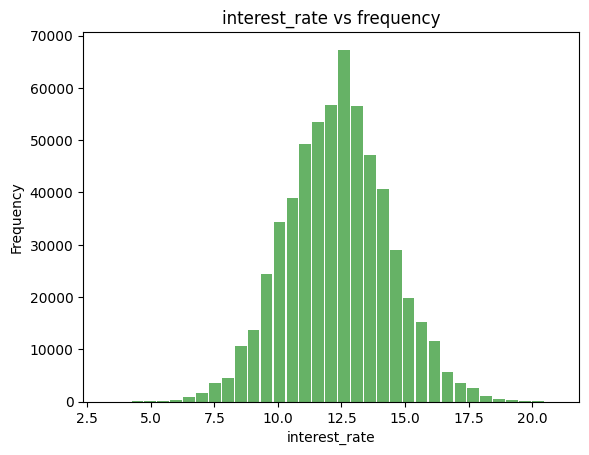

In [12]:
for i in numeric_features:
  plt.hist(df[i],bins=35,alpha=0.6,rwidth=0.90,color='green')
  plt.xlabel(i)
  plt.ylabel('Frequency')
  plt.title(f'{i} vs frequency')
  plt.show()

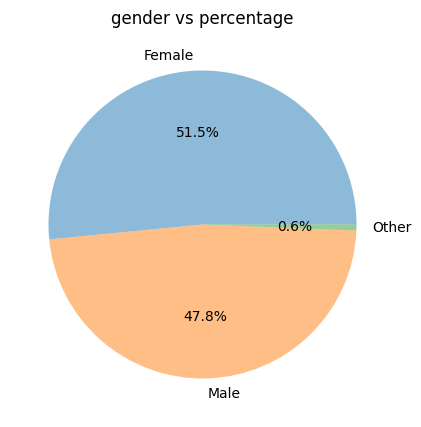

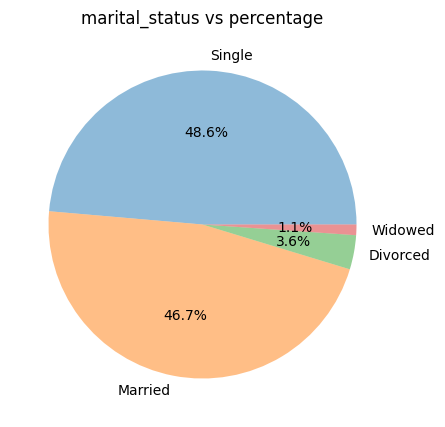

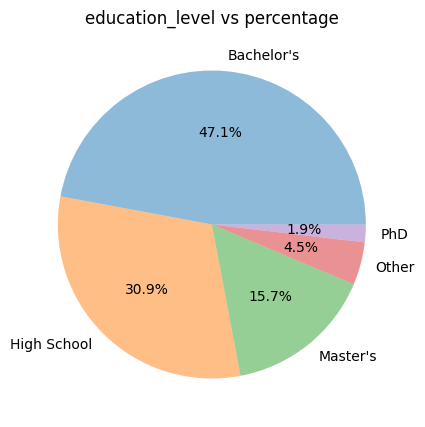

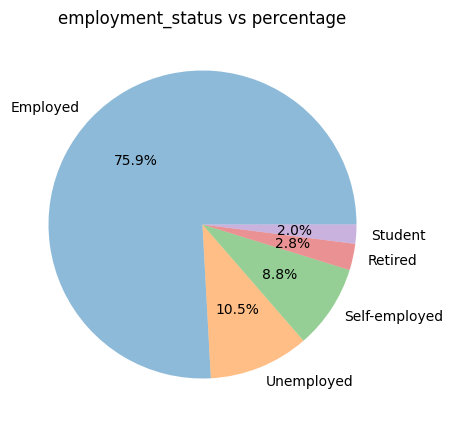

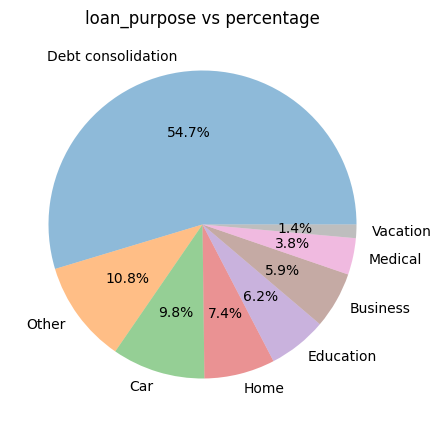

In [13]:
for j in categorical_features:
  plt.figure(figsize=(10,5))
  plt.pie(df[j].value_counts(), labels=df[j].value_counts().index, autopct='%1.1f%%',wedgeprops={"alpha": 0.5})
  plt.title(f'{j} vs percentage')
  plt.show()

## Data Preparation

In [8]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
def label_encoder(df,cols):
  df[cols]=df[cols].apply(le.fit_transform)
  df['grade_subgrade']=df[['grade_subgrade']].apply(le.fit_transform)
  return df
label_encoder(df,categorical_features)

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,29367.99,0.084,736,2528.42,13.67,0,2,1,2,6,12,1.0
1,22108.02,0.166,636,4593.10,12.92,1,1,2,0,2,17,0.0
2,49566.20,0.097,694,17005.15,9.76,1,2,1,0,2,14,1.0
3,46858.25,0.065,533,4682.48,16.10,0,2,1,0,2,25,1.0
4,25496.70,0.053,665,12184.43,10.21,1,1,1,0,6,15,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
593989,23004.26,0.152,703,20958.37,10.92,0,2,1,0,0,12,1.0
593990,35289.43,0.105,559,3257.24,14.62,1,2,0,0,2,29,1.0
593991,47112.64,0.072,675,929.27,14.13,0,1,0,0,2,10,1.0
593992,76748.44,0.067,740,16290.40,9.87,1,2,0,0,2,6,1.0


In [9]:
X=df.drop('loan_paid_back',axis=1)
y=df['loan_paid_back']

In [11]:
from sklearn.model_selection import train_test_split
x_train, x_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

## Model Training

In [12]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import KFold, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score

## XGBClassifier

In [88]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    device="cuda",
    tree_method="hist",
    objective="binary:logistic",
    use_label_encoder=False,
    eval_metric="logloss",
    scale_pos_weight=pos_weight,
    random_state=42
)

param_dist = {
"n_estimators": [600, 800],
"max_depth": [2, 4],
"subsample": [0.6, 0.7],
"colsample_bytree": [0.5, 0.6],
"min_child_weight": [2, 3, 4],
"reg_alpha": [0.01, 0.05],
"reg_lambda": [1]
}

rs = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=10,
    scoring='roc_auc',
    n_jobs=-1,
    cv=cv,
    random_state=42
)

rs.fit(x_train, y_train)

best = rs.best_estimator_
y_pred = best.predict(x_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:53:35] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Accuracy: 0.8675662253049268


## LGBMClassifier

In [14]:
# Use stratified splits for classification
cv = KFold(n_splits=5, shuffle=True, random_state=42)

lgb = LGBMClassifier(
    #device_type='gpu',
    objective='binary',
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

param_dist = {
    "n_estimators": [200, 400],
    "num_leaves": [31, 41],
    "max_depth": [2, 4],
    "min_split_gain": [0, 0.01, 0.1],
    "subsample": [0.4, 0.6],
    "colsample_bytree": [0.6, 0.8],
    "reg_alpha": [0.01, 0.1],
    "reg_lambda": [1]
}


rs = RandomizedSearchCV(
    estimator=lgb,
    param_distributions=param_dist,
    n_iter=10,
    scoring='roc_auc',
    n_jobs=-1,
    cv=cv,
    random_state=42
)

rs.fit(x_train, y_train)

best = rs.best_estimator_

X_tr, X_val, y_tr, y_val = train_test_split(x_train, y_train, test_size=0.20, stratify=y_train, random_state=42)

best.set_params(**rs.best_params_)
best.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric='auc'
)

y_pred = best.predict(x_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))

[LightGBM] [Info] Number of positive: 356009, number of negative: 89486
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.109509 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1329
[LightGBM] [Info] Number of data points in the train set: 445495, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

## TabNet

In [87]:
#!pip install pytorch-tabnet

In [84]:
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.utils.class_weight import compute_sample_weight

# ensure numpy arrays (TabNet accepts numpy)
X_tr = x_train.values if hasattr(x_train, "values") else np.asarray(x_train)
y_tr = y_train.values.ravel() if hasattr(y_train, "values") else np.asarray(y_train).ravel()
X_te = x_test.values if hasattr(x_test, "values") else np.asarray(x_test)
y_te = y_test.values.ravel() if hasattr(y_test, "values") else np.asarray(y_test).ravel()

sample_weights = compute_sample_weight(class_weight='balanced', y=y_tr)

clf = TabNetClassifier(
    verbose=1,
    device_name='cuda'
)


clf.fit(
    X_tr, y_tr,
    eval_set=[(X_te, y_te)],
    eval_name=['test'],
    eval_metric=['auc'],
    max_epochs=10,
    patience=20,
    batch_size=1024,
    virtual_batch_size=128,
    weights=sample_weights,
    drop_last=False
)

y_pred = clf.predict(X_te)

print("Test Accuracy:", accuracy_score(y_te, y_pred))

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.39099 | test_auc: 0.90867 |  0:00:27s
epoch 1  | loss: 0.37059 | test_auc: 0.9122  |  0:00:48s
epoch 2  | loss: 0.36747 | test_auc: 0.91244 |  0:01:07s
epoch 3  | loss: 0.3681  | test_auc: 0.91243 |  0:01:27s
epoch 4  | loss: 0.36653 | test_auc: 0.91268 |  0:01:49s
epoch 5  | loss: 0.36626 | test_auc: 0.91257 |  0:02:08s
epoch 6  | loss: 0.36528 | test_auc: 0.91263 |  0:02:31s
epoch 7  | loss: 0.36852 | test_auc: 0.91335 |  0:02:51s
epoch 8  | loss: 0.36579 | test_auc: 0.91328 |  0:03:12s
epoch 9  | loss: 0.36516 | test_auc: 0.91331 |  0:03:33s
Stop training because you reached max_epochs = 10 with best_epoch = 7 and best_test_auc = 0.91335


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Test Accuracy: 0.8635342048333741


## Prediction for Test-dataset

In [15]:
df_test=pd.read_csv(test)
id=df_test['id']
df_test=df_test.drop('id',axis=1)
df_test.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,28781.05,0.049,626,11461.42,14.73,Female,Single,High School,Employed,Other,D5
1,46626.39,0.093,732,15492.25,12.85,Female,Married,Master's,Employed,Other,C1
2,54954.89,0.367,611,3796.41,13.29,Male,Single,Bachelor's,Employed,Debt consolidation,D1
3,25644.63,0.110,671,6574.30,9.57,Female,Single,Bachelor's,Employed,Debt consolidation,C3
4,25169.64,0.081,688,17696.89,12.80,Female,Married,PhD,Employed,Business,C1


In [16]:
label_encoder(df_test,categorical_features)

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,28781.05,0.049,626,11461.42,14.73,0,2,1,0,6,19
1,46626.39,0.093,732,15492.25,12.85,0,1,2,0,6,10
2,54954.89,0.367,611,3796.41,13.29,1,2,0,0,2,15
3,25644.63,0.110,671,6574.30,9.57,0,2,0,0,2,12
4,25169.64,0.081,688,17696.89,12.80,0,1,4,0,0,10
...,...,...,...,...,...,...,...,...,...,...,...
254564,92835.97,0.068,744,29704.00,13.48,0,2,0,0,2,6
254565,48846.47,0.091,634,20284.33,9.58,0,1,1,0,2,18
254566,20668.52,0.096,718,26387.55,9.00,1,2,2,0,2,13
254567,34105.09,0.094,739,11107.36,9.81,1,2,0,0,0,11


In [17]:
loan_paid_back=best.predict(df_test)
#test_pred = df_test.values
#loan_paid_back = clf.predict(test_pred)

In [18]:
submission=pd.DataFrame({'id':id,'loan_paid_back':loan_paid_back})
submission.to_csv('submission.csv',index=False)